In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib
import os

Note: you may need to restart the kernel to use updated packages.


In [7]:
df = pd.read_csv("../data/StudentsPerformance.csv")

In [8]:
X = df.drop("math score", axis=1)

y = df["math score"]

In [9]:
categorical_features = X.select_dtypes(include=["object"]).columns

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

In [13]:
linear_pipeline.fit(X_train, y_train)

decision_tree_pipeline.fit(X_train, y_train)

random_forest_pipeline.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


In [14]:
linear_pred = linear_pipeline.predict(X_test)

tree_pred = decision_tree_pipeline.predict(X_test)

forest_pred = random_forest_pipeline.predict(X_test)

In [15]:
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    return mae, mse, rmse, r2

In [16]:
linear_results = evaluate_model(y_test, linear_pred)

tree_results = evaluate_model(y_test, tree_pred)

forest_results = evaluate_model(y_test, forest_pred)

print("Linear Regression")
print(linear_results)

print()

print("Decision Tree")
print(tree_results)

print()

print("Random Forest")
print(forest_results)

Linear Regression
(4.214763142474854, 29.095169866715526, np.float64(5.393993869732847), 0.8804332983749563)

Decision Tree
(6.24, 60.52, np.float64(7.77946013551069), 0.7512928497927167)

Random Forest
(4.665547023809524, 36.31139799185091, np.float64(6.0258939578996005), 0.8507781838302096)


In [17]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE": [
        linear_results[0],
        tree_results[0],
        forest_results[0]
    ],

    "RMSE": [
        linear_results[2],
        tree_results[2],
        forest_results[2]
    ],

    "R2 Score": [
        linear_results[3],
        tree_results[3],
        forest_results[3]
    ]
})

comparison_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4.214763,5.393994,0.880433
1,Decision Tree,6.240000,7.779460,0.751293
2,Random Forest,4.665547,6.025894,0.850778


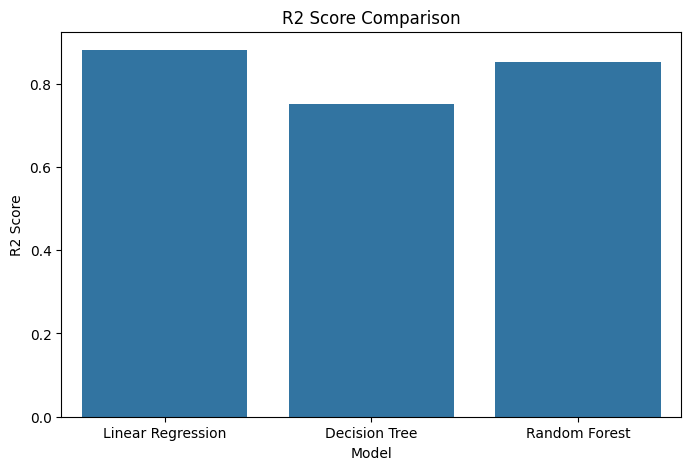

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="R2 Score",
    data=comparison_df
)

plt.title("R2 Score Comparison")
plt.ylabel("R2 Score")

plt.show()

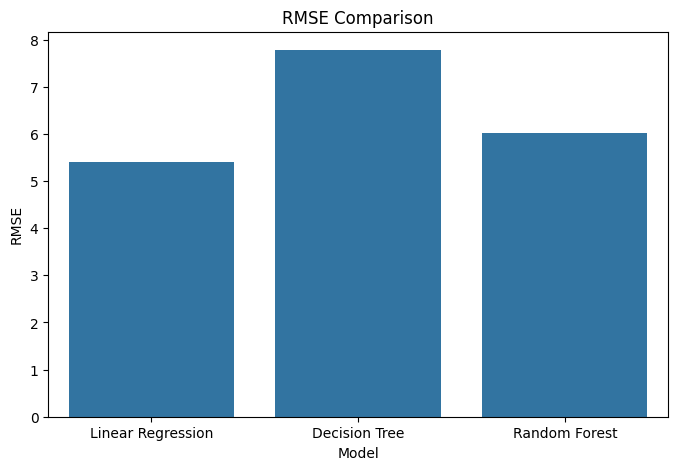

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="RMSE",
    data=comparison_df
)

plt.title("RMSE Comparison")
plt.ylabel("RMSE")

plt.show()

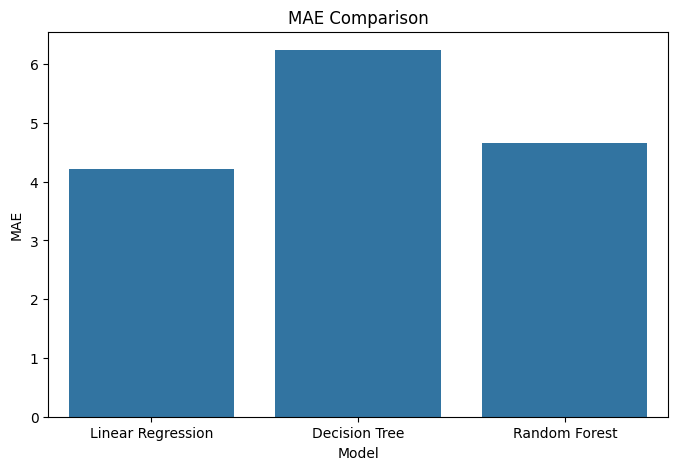

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="MAE",
    data=comparison_df
)

plt.title("MAE Comparison")
plt.ylabel("MAE")

plt.show()

In [21]:
best_model_name = comparison_df.loc[
    comparison_df["R2 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Linear Regression


In [26]:
if best_model_name == "Linear Regression":
    best_model = linear_pipeline

elif best_model_name == "Decision Tree":
    best_model = decision_tree_pipeline

else:
    best_model = random_forest_pipeline


joblib.dump(
    best_model,
    "../models/student_score_model.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


In [27]:
loaded_model = joblib.load(
    "../models/student_score_model.pkl"
)

sample = X.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Actual Score:", y.iloc[0])
print("Predicted Score:", prediction[0])

Actual Score: 72
Predicted Score: 66.110213316221


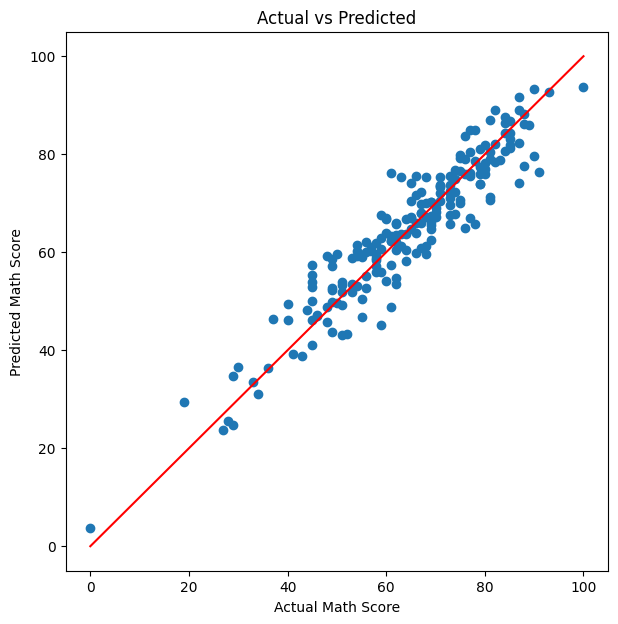

In [28]:
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_best)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Actual vs Predicted")

plt.show()